In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from astropy.timeseries import LombScargle

In [2]:
import random

In [3]:
import h5py

In [4]:
import pandas as pd

In [5]:
import astropy.units as u

In [6]:
#---------------------------------------------------------- Data Upload
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------

VVV_data = fits.open('VVV_Sample.fits')

Id_b278, Id_b279 = VVV_data[1].data,VVV_data[11].data

Ks_b278, Ks_b279 = VVV_data[2].data, VVV_data[12].data
Ks_err_b278, Ks_err_b279 = VVV_data[5].data, VVV_data[15].data
Ks_mjd_b278, Ks_mjd_b279 = VVV_data[8].data, VVV_data[18].data

#---------------------------------------------------------- Removing np.nan 
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------

# Remove missing values (NaNs) from all Ks-related data arrays

def remove_nans(array2d):
    return [row[~np.isnan(row)] for row in array2d]

def _safe_norm(x):
    xmin, xmax = np.min(x), np.max(x)
    return (x - xmin) / (xmax - xmin)

Ks_b278 = remove_nans(Ks_b278)
Ks_b279 = remove_nans(Ks_b279)

Ks_err_b278 = remove_nans(Ks_err_b278)
Ks_err_b279 = remove_nans(Ks_err_b279)

Ks_mjd_b278 = remove_nans(Ks_mjd_b278)
Ks_mjd_b279 = remove_nans(Ks_mjd_b279)

In [7]:
VVV_data.info()

Filename: VVV_Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ID_B278       1 ImageHDU         7   (304,)   int64   
  2  KS_B278       1 ImageHDU         8   (523, 304)   float64   
  3  H_B278        1 ImageHDU         8   (32, 304)   float64   
  4  J_B278        1 ImageHDU         8   (25, 304)   float64   
  5  KS_ERR_B278    1 ImageHDU         8   (523, 304)   float64   
  6  H_ERR_B278    1 ImageHDU         8   (32, 304)   float64   
  7  J_ERR_B278    1 ImageHDU         8   (25, 304)   float64   
  8  KS_MJD_B278    1 ImageHDU         8   (523, 304)   float64   
  9  H_MJD_B278    1 ImageHDU         8   (32, 304)   float64   
 10  J_MJD_B278    1 ImageHDU         8   (25, 304)   float64   
 11  ID_B279       1 ImageHDU         7   (286,)   int64   
 12  KS_B279       1 ImageHDU         8   (960, 286)   float64   
 13  H_B279        1 ImageHDU         8   (14, 286)   float64   
 14  J_B279        1

In [8]:
def get_phases(t_data, u_data, trial_period):
    threshold = np.percentile(u_data, 2)  # percentil 2% = los más bajos
    idx = np.argmin(np.abs(u_data - threshold))  # índice del valor más cercano al percentil
    t0 = t_data[idx]

    return ((t_data - t0) / trial_period) % 1

In [9]:
def get_test_periods(period_i, period_f, n, linear=True):
    if linear:
        return np.linspace(period_i, period_f, n)

    THRESHOLD = 30.0

    if period_f <= THRESHOLD:
        # Todo el rango es fino: linspace normal
        return np.linspace(period_i, period_f, n)

    if period_i >= THRESHOLD:
        # Todo el rango es "largo": densidad decreciente con ruido
        u = np.sort(np.random.uniform(0, 1, n))
        # Raíz cuadrada concentra puntos al inicio (períodos cortos) y dispersa al final
        u = u ** 1.8  
        return period_i + u * (period_f - period_i)

    # Rango mixto: parte fina hasta THRESHOLD, parte dispersa después
    fine_fraction = (THRESHOLD - period_i) / (period_f - period_i)
    n_fine   = 2*int(n * fine_fraction)
    n_sparse = n - n_fine

    fine_periods = np.linspace(period_i, THRESHOLD, n_fine)

    u = np.sort(np.random.uniform(0, 1, n_sparse))
    u = u ** 1.8  # Decrecimiento no lineal con dispersión
    # Añadir ruido suave para que no sea completamente determinista
    noise = np.random.uniform(-0.5/n_sparse, 0.5/n_sparse, n_sparse)
    u = np.clip(u + noise, 0, 1)
    u = np.sort(u)
    sparse_periods = THRESHOLD + u * (period_f - THRESHOLD)

    return np.concatenate([fine_periods, sparse_periods])

In [10]:
N = Id_b278.shape[0]
n = 10
selected_idx = random.sample(range(N), n)

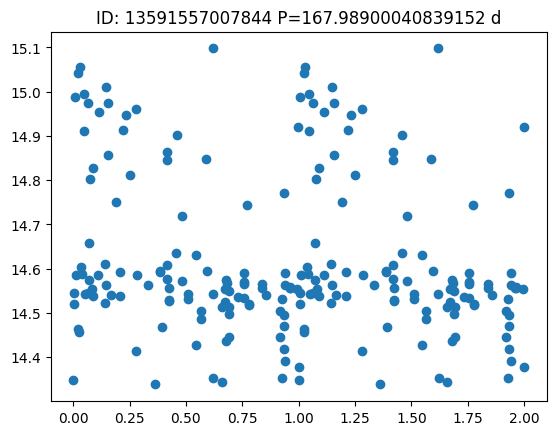

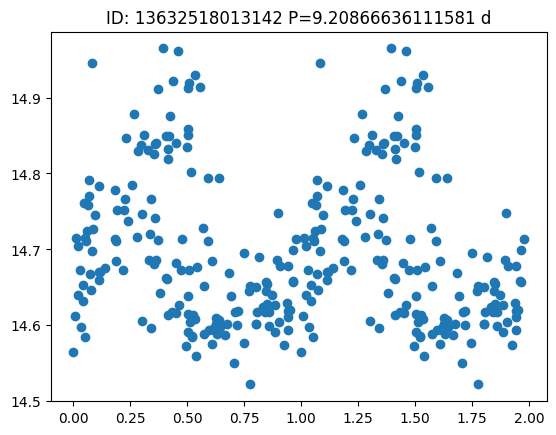

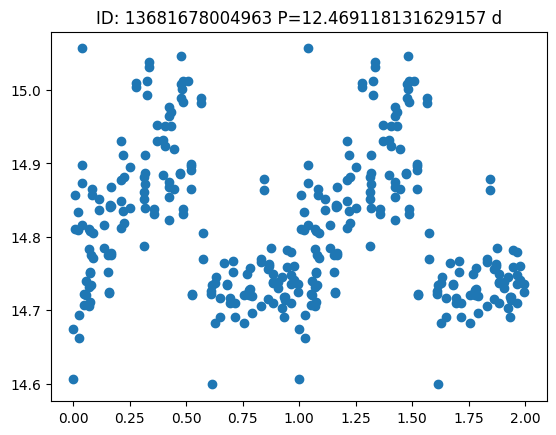

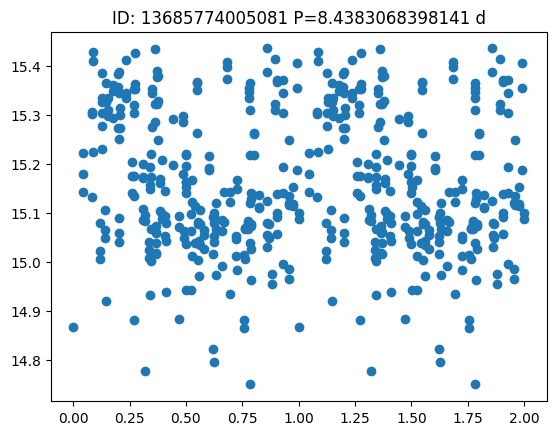

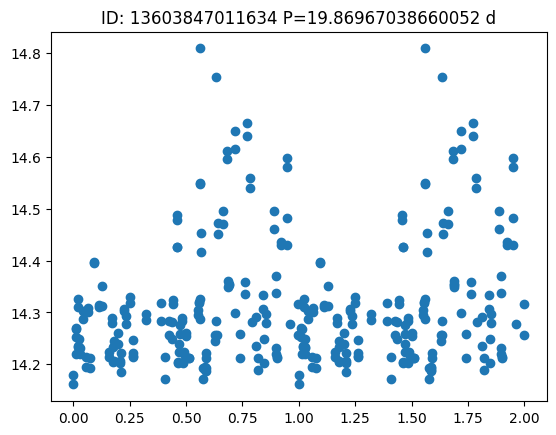

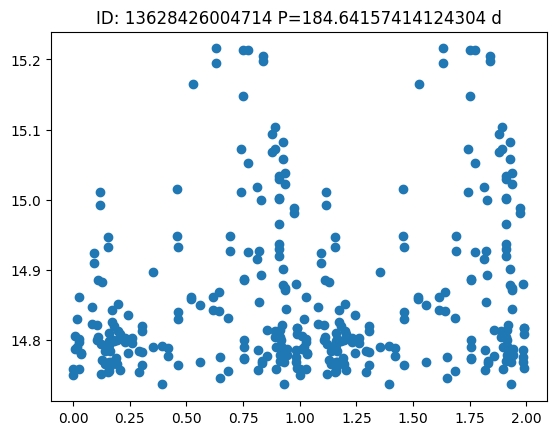

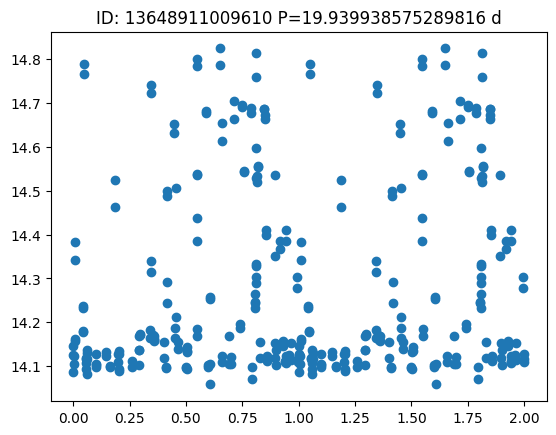

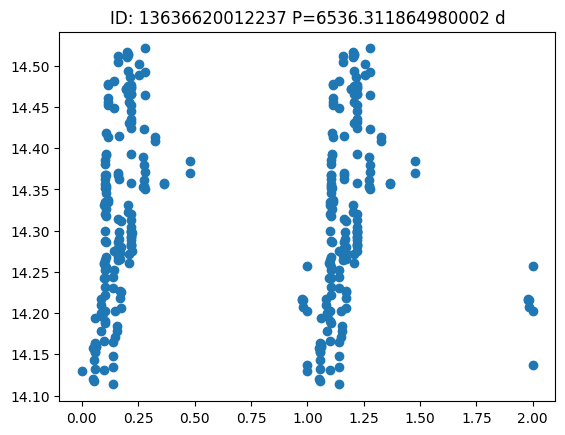

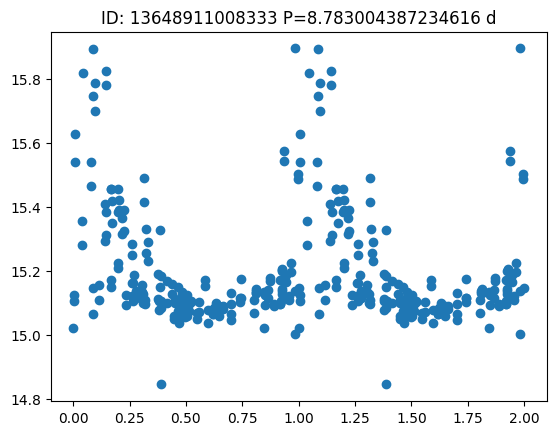

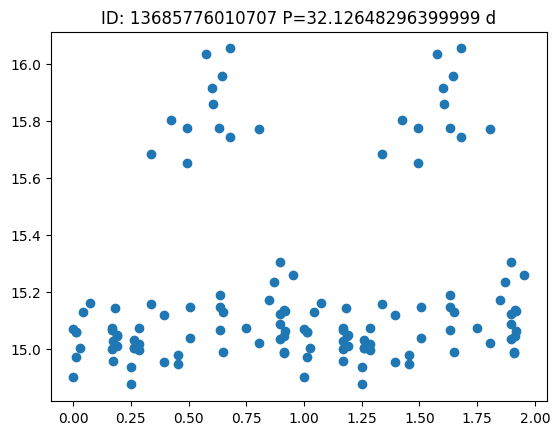

In [13]:
resultados = np.zeros((n,3)) #ID, frecuencia hallada, período hallado
CUSTOM = False
P_INI = 0.1
P_FIN = 101
P_NUM=1000

for i, idx in enumerate(selected_idx):
    t, ks, id, dks = Ks_mjd_b278[idx], Ks_b278[idx], Id_b278[idx], Ks_err_b278[idx]

    if CUSTOM:
        frequency = get_test_periods(P_INI, P_FIN, P_NUM, linear=True)
        power = LombScargle(t, ks, dks).power(frequency)
    else:
        frequency, power = LombScargle(t, ks).autopower()
    best_frequency = frequency[np.argmax(power)]
    period = 1/best_frequency
    resultados[i,0] = id
    resultados[i,1] = best_frequency
    resultados[i,2] = period

    phases1 = get_phases(t,ks,period)
    phases2 = phases1+1
    phases = np.append(phases1, phases2)

    ks2 = ks.copy()
    mag = np.append(ks,ks2)

    plt.scatter(phases,mag)
    plt.title(f"ID: {id} P={period} d")
    plt.show()
